In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from open_ephys.analysis import Session
import os
import re
from scipy.signal import butter, filtfilt, lfilter
from collections import defaultdict
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors



# ==== Select Session ====
w = 1  # recordnode index 1 = Record Node 111 RAW is Offline Filtered
u = 0       # recordnode index 0 = Record Node 106 is Online Filtered


m_wave_start, m_wave_end = 1.5, 4
h_wave_start, h_wave_end = 4.5, 10

def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    node_path = os.path.join(session_dir, record_node_name)
    
    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}
    
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info

# ==== Load Session ====
# ==== Load Session ====
#directory = '1-21-2026/HRPilot-06_Test1_2026-01-21_10-53-20_001'
#directory = '1-21-2026/HRPilot-06_Test2_2026-01-21_19-59-58_003'
#directory = '1-21-2026/HRPilot-08_Test1_2026-01-21_11-48-40_002'
#directory = '1-21-2026/HRPilot-08_Test2_2026-01-21_20-22-57_004'
#directory = '1-21-2026/HRPilot-09_Test12026-01-21_18-17-01_001'
#directory = '1-21-2026/HRPilot-10_Test1_2026-01-21_17-30-13_001'
#directory = '1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002'

#directory = 'HRPilot-05_FirstChronicTest1_2025-08-27_17-17-00_001'

#directory = '3-13-26-Chronic\HRPilot-12_Chronic_Test12026-03-13_11-40-22_001'
directory = '3-13-26\HRPilot-12_Chronic_Test2_2026-03-13_13-54-40_001'


session = Session(directory)
print('Pass Initial Test, Moving on to Loading Session...\n')

# === Scan structure ===
record_node_name = "Record Node 106" if w == 0 else "Record Node 111"
structure = scan_experiment_structure(directory, record_node_name)

Pass Initial Test, Moving on to Loading Session...



<>:52: SyntaxWarning: invalid escape sequence '\H'
<>:52: SyntaxWarning: invalid escape sequence '\H'
C:\Users\yahri\AppData\Local\Temp\ipykernel_39284\1230202394.py:52: SyntaxWarning: invalid escape sequence '\H'
  directory = '3-13-26\HRPilot-12_Chronic_Test2_2026-03-13_13-54-40_001'


In [3]:
# === Flatten experiment-recording pairs to loop ===
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

Processing: x=0, y=recording1, exp=experiment1, yy=recording1

EXPERIMENT1, Recording 1
Open Ephys GUI Recording
ID: 0x214ffe77100
Format: Binary
Directory: 3-13-26\HRPilot-12_Chronic_Test2_2026-03-13_13-54-40_001\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0
Channels: ['CH1', 'CH5', 'CH10', 'CH12', 'ADC1'] 

Loaded 489 MessageCenter entries
[Time: 1423.861600 s] Message: first rat with 5mm spacing with 1mm recording sites
[Time: 1454.071000 s] Message: Starting at 0.10 mA
[Time: 1456.136000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1462.254400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1465.275400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1468.564000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1471.737800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1474.567600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1477.856200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1480.991800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 1484.815800 s] Mess

C:\Users\yahri\AppData\Local\Temp\ipykernel_39284\420436185.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\yahri\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


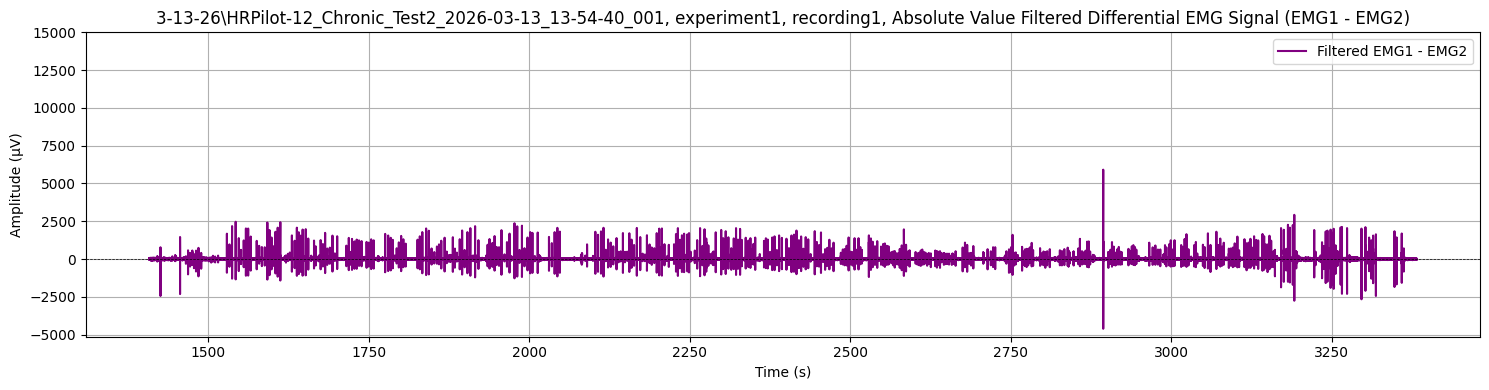

In [4]:
x = 0
exp = "experiment1"

y = f"recording{x + 1}"  # sequential label used in some parts of your code
yy = y
#y = f"recording{x}"  # sequential label used in some parts of your code
v = f"Record Node 106" if w == 0 else f"Record Node 111"
vv = f"Record Node 111" if u == 0 else f"Record Node 106"
i = 1

try:
    recording = session.recordnodes[w].recordings[x]
    #recording_offline = session.recordnodes[w].recordings[x]
except IndexError:
    print(f"No recording {x+1} found in {exp}/{yy}")
    

print(f"Processing: x={x}, y={y}, exp={exp}, yy={yy}")

# ==== Sync Setup ====
print(f"\n{exp.upper()}, Recording {x+1}")
print(recording)

# Only add sync line if a main one doesn't already exist
has_main_sync = any(sync.get("main", True) for sync in recording.sync_lines)
if not has_main_sync:
    recording.add_sync_line(1, 100, 'Rhythm Data', main=True)

#recording.compute_global_timestamps()

metadata = recording.continuous[0].metadata
channel_names = metadata.channel_names
print("Channels:", channel_names, '\n')

timestamps = recording.continuous[0].timestamps
#data_offline =  recording_offline.continuous[0].get_samples(start_sample_index=0, end_sample_index=len(timestamps))
data = recording.continuous[0].get_samples(start_sample_index=0, end_sample_index=len(timestamps))
sample_rate = metadata.sample_rate

# ==== EMG Processing (Pull Channel 11 Index 4)====

# ==== EMG Processing ====
emg1_raw = data[:, 2]
emg2_raw = data[:, 3]
differential = (emg2_raw - emg1_raw)
lowcut = 100
highcut = 1000

b, a = butter(2, np.array([lowcut, highcut])/(sample_rate/2), btype='bandpass')

differential_filt = lfilter(b, a, differential)
differential_abs = np.abs(differential_filt)
differential_emg = differential_filt



#differential_emg = data[:, 3]



# ==== Load ADC1 (for stim detection) ====
adc1 = np.abs(data[:, 4])  # adjust if your ADC1 channel index differs

# ==== Sync Events ====
events = recording.events
sync_events = events[(events.line == 1) & (events.processor_id == 100) &
                        (events.stream_name == 'Rhythm Data') & (events.state == 1)]
sync_timestamps = sync_events['timestamp'].to_numpy()

# ==== Load MessageCenter ====
messagecenter_dir = os.path.join(directory, v, exp, yy, "events", "MessageCenter")
if not os.path.exists(messagecenter_dir):
    print(f"MessageCenter directory not found for {exp}/{yy}")
    

texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
message_entries = list(zip(timestamps_msg, decoded_texts))
print(f"Loaded {len(decoded_texts)} MessageCenter entries")

# ==== Debug Print ====
for text, time in zip(decoded_texts, timestamps_msg):
    print(f"[Time: {time:.6f} s] Message: {text}")

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {exp}, {yy}, Absolute Value Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
plt.ylim(top=15000)
plt.tight_layout()
plt.show()


In [5]:
# ==== Peri-Stimulus Analysis with Shaded Stimulus Duration ====
pre_event_time = 5   # ms before calculated stim start
post_event_time = 20 # ms after calculated stim start
stim_threshold = 0.1 # ADC1 threshold to detect pulse (adjust if needed)
offstim_threshold = 3

peri_stim_segments = []
peri_stim_segments_adc1 = []
segment_stim_end_times = []
segment_stim_start_times = []

In [6]:
for stamp in sync_timestamps:
        # First, find approximate sample index around the sync pulse
        #idx_start = np.searchsorted(timestamps, stamp)
        #idx_end   = np.searchsorted(timestamps, stamp + 0.010)
        #idx_center = (idx_start + idx_end)/2

        idx_search_start = np.searchsorted(timestamps, stamp - 0.00002)  # 10 ms before sync
        idx_search_end   = np.searchsorted(timestamps, stamp + 0.010)  # 10 ms after sync

        if idx_search_start < 0 or idx_search_end > len(timestamps):
            continue

        adc1_segment_for_detection = adc1[idx_search_start:idx_search_end]
        time_segment_for_detection = timestamps[idx_search_start:idx_search_end]

        # Detect true stim start: first crossing above threshold in that window
        above_idxs = np.where(adc1_segment_for_detection > stim_threshold)[0]
        
        if len(above_idxs) == 0:
            continue
        stim_start_idx = idx_search_start + above_idxs[0]
        stim_start_time = timestamps[stim_start_idx]

        # Now define peri-stimulus window around this stim_start_time
        idx_pre  = int(stim_start_idx - (pre_event_time / 1000) * sample_rate)
        idx_post = int(stim_start_idx + (post_event_time / 1000) * sample_rate)

        if idx_pre < 0 or idx_post > len(timestamps):
            continue

        # Extract windows
        time_window = timestamps[idx_pre:idx_post]
        time_zeroed = time_window - stim_start_time  # in seconds

        emg_window  = differential_emg[idx_pre:idx_post]
        adc1_window = adc1[idx_pre:idx_post]

        # Detect stim end: first time after stim_start where ADC1 falls back below threshold
        post_onset_mask = (time_zeroed >= 0)
        adc1_post_onset = adc1_window[post_onset_mask]
        time_post_onset = time_zeroed[post_onset_mask]

        below_idxs = np.where(adc1_post_onset < offstim_threshold)[0]
        if len(below_idxs) > 0:
            stim_end_time = time_post_onset[below_idxs[0]] * 1000  # convert to ms
        else:
            stim_end_time = post_event_time

        # Save for grouping
        peri_stim_segments.append((time_zeroed * 1000, emg_window, stim_end_time))
        peri_stim_segments_adc1.append(adc1_window)
        segment_stim_start_times.append(stim_start_time)
        segment_stim_end_times.append(stim_end_time)


In [7]:
print(time_window)
print(idx_search_start)
print(idx_search_end)
print(peri_stim_segments_adc1)
print(peri_stim_segments)
print(stim_end_time)
type(stim_end_time)

[3362.6232 3362.6234 3362.6236 3362.6238 3362.624  3362.6242 3362.6244
 3362.6246 3362.6248 3362.625  3362.6252 3362.6254 3362.6256 3362.6258
 3362.626  3362.6262 3362.6264 3362.6266 3362.6268 3362.627  3362.6272
 3362.6274 3362.6276 3362.6278 3362.628  3362.6282 3362.6284 3362.6286
 3362.6288 3362.629  3362.6292 3362.6294 3362.6296 3362.6298 3362.63
 3362.6302 3362.6304 3362.6306 3362.6308 3362.631  3362.6312 3362.6314
 3362.6316 3362.6318 3362.632  3362.6322 3362.6324 3362.6326 3362.6328
 3362.633  3362.6332 3362.6334 3362.6336 3362.6338 3362.634  3362.6342
 3362.6344 3362.6346 3362.6348 3362.635  3362.6352 3362.6354 3362.6356
 3362.6358 3362.636  3362.6362 3362.6364 3362.6366 3362.6368 3362.637
 3362.6372 3362.6374 3362.6376 3362.6378 3362.638  3362.6382 3362.6384
 3362.6386 3362.6388 3362.639  3362.6392 3362.6394 3362.6396 3362.6398
 3362.64   3362.6402 3362.6404 3362.6406 3362.6408 3362.641  3362.6412
 3362.6414 3362.6416 3362.6418 3362.642  3362.6422 3362.6424 3362.6426
 3362.642

numpy.float64

In [8]:
# ==== Dynamically determine stimulation groups based on event messages ====

# First, extract only trigger messages and stim setting messages
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER")
stim_pattern = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups = []
current_group = []
current_amp = None
trigger_times = []

for t, msg in message_entries:
    if stim_pattern.search(msg):
        # Save the previous group if any
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        # Start new group
        current_amp = float(stim_pattern.search(msg).group(1))
        current_group = []
    elif trigger_pattern.search(msg):
        if current_amp is not None:
            current_group.append(t)

# Don't forget to save the last group
if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))


In [9]:
# ==== Match trigger times to peri_stim_segments ====
# Create dictionary to associate each stim amplitude to its segments
stim_intensities = []
m_wave_peaks = []
h_wave_peaks = []

In [10]:
print(m_peak_amp)

NameError: name 'm_peak_amp' is not defined

C:\Users\yahri\AppData\Local\Temp\ipykernel_107704\2794024432.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('copper')


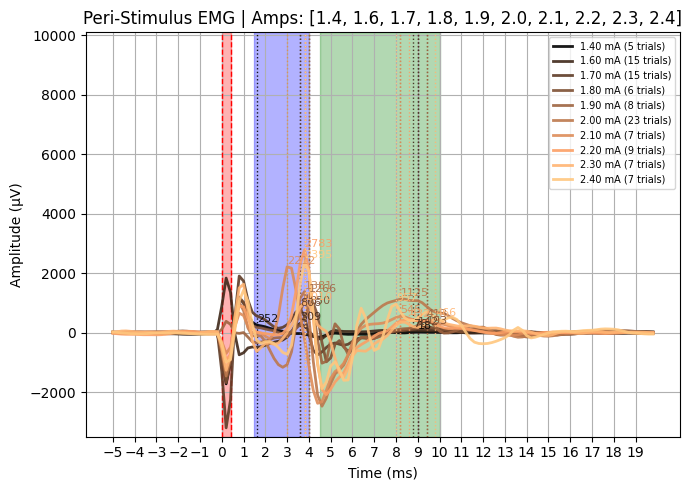

In [ ]:

for stim_amp, trigger_times_group in stim_groups:
    # For each trigger time, find matching peri_stim segment (by start time)
    group_data = []
    group_start_times = []
    group_end_times = []
    group_adc1 = []

    for trig_time in trigger_times_group:
        # Find closest stim_start_time to this trigger time
        idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
        # Extra check: ensure it's reasonably close (e.g., within 100 ms)
        if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
            group_data.append(peri_stim_segments[idx_match])
            group_adc1.append(peri_stim_segments_adc1[idx_match])
            group_start_times.append(segment_stim_start_times[idx_match])
            group_end_times.append(segment_stim_end_times[idx_match])

    if not group_data:
        continue  # skip if no valid matching data

    # Proceed with same logic as original
    time_ms_matrix = np.stack([gd[0] for gd in group_data])
    emg_matrix     = np.stack([gd[1] for gd in group_data])

    avg_time_ms = time_ms_matrix[0]  # identical for all in group
    avg_adc1 = np.mean(group_adc1, axis=0)
    avg_emg     = np.mean(emg_matrix, axis=0)
    avg_end_ms  = np.mean(group_end_times)

    stim_intensities.append(stim_amp)

    #plt.figure(figsize=(7, 5))

    for (_, trace, _) in group_data:
        #plt.plot(avg_time_ms, trace, color='red', alpha=0.6)
    #plt.plot(avg_time_ms, avg_emg, color='black', linewidth=2, label='Average EMG')

    #plt.axvline(x=0, color='red', linestyle='--', label='_nolegend_')
    #plt.axvline(x=stim_end_time, color='red', linestyle='--', label='Stim Start/End')
    #plt.axvspan(0, stim_end_time, color='red', alpha=0.3)

    

    #plt.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.3)
    #plt.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.3)

        m_wave_mask = (avg_time_ms >= m_wave_start) & (avg_time_ms <= m_wave_end)
    m_wave_time_window = avg_time_ms[m_wave_mask]
    m_wave_emg_window = avg_emg[m_wave_mask]
    m_wave_peak_idx = np.argmax(m_wave_emg_window)
    m_wave_peak_time = m_wave_time_window[m_wave_peak_idx]
    m_wave_peak_amp = m_wave_emg_window[m_wave_peak_idx]
    m_wave_peaks.append(m_wave_peak_amp)

    h_wave_mask = (avg_time_ms >= h_wave_start) & (avg_time_ms <= h_wave_end)
    h_wave_time_window = avg_time_ms[h_wave_mask]
    h_wave_emg_window = avg_emg[h_wave_mask]
    h_wave_peak_idx = np.argmax(h_wave_emg_window)
    h_wave_peak_time = h_wave_time_window[h_wave_peak_idx]
    h_wave_peak_amp = h_wave_emg_window[h_wave_peak_idx]
    h_wave_peaks.append(h_wave_peak_amp)
############################ THE CODE BELOW IS WITH THE ADC LINE PLOT ADDED ##################

# ==== Parameters ====
group_size = 25       # number of amplitudes to overlay per figure
selected_amps = [1.60, 1.40, 1.70, 1.80, 1.90, 2.00, 2.10, 2.20, 2.30, 2.40] #None # e.g., [0.5, 1.0, 1.5, 2.0]; None = use all

# ==== Choose amplitudes to plot ====
if selected_amps is None:
    amps_to_plot = sorted(set(stim_intensities))
else:
    amps_to_plot = [a for a in sorted(set(stim_intensities)) if a in selected_amps]

# ==== Group amplitudes in chunks ====
for g in range(0, len(amps_to_plot), group_size):
    amps_group = amps_to_plot[g:g + group_size]
    plt.figure(figsize=(7, 5))

    # Create gradient from dark black to light grey with decreasing opacity
    # Create copper sequential colormap
    cmap = cm.get_cmap('copper')
    norm = mcolors.Normalize(vmin=min(amps_group), vmax=max(amps_group))

    colors = [
        (*cmap(norm(stim_amp))[:3], 0.9)  # RGB from copper + fixed alpha
        for stim_amp in amps_group
    ]


    # Plot stim start/end lines and M/H-wave windows only once
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.axvline(stim_end_time, color='red', linestyle='--', linewidth=1)
    plt.axvspan(0, stim_end_time, color='red', alpha=0.3)
    plt.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.3)
    plt.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.3)

    # Track max y-values for proper y-axis limits
    max_y_values = []

    for color, stim_amp in zip(colors, amps_group):
        # Collect peri-stim segments for this amplitude
        group_data, group_end_times = [], []

        trig_times_amp = [tt for amp, times in stim_groups if amp == stim_amp for tt in times]

        for trig_time in trig_times_amp:
            idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
            if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
                group_data.append(peri_stim_segments[idx_match])
                group_end_times.append(segment_stim_end_times[idx_match])

        if not group_data:
            continue

        # Average across trials
        time_ms_matrix = np.stack([gd[0] for gd in group_data])
        emg_matrix     = np.stack([gd[1] for gd in group_data])
        avg_time_ms    = time_ms_matrix[0]
        avg_emg        = np.mean(emg_matrix, axis=0)
        avg_end_ms     = np.mean(group_end_times)

        # Number of trials in this amplitude
        n_trials = len(group_data)

        # Plot only the average EMG
        plt.plot(avg_time_ms, avg_emg, color=color, linewidth=2,
                label=f"{stim_amp:.2f} mA ({n_trials} trials)")

        # Annotate M-wave peak
        m_wave_mask = (avg_time_ms >= m_wave_start) & (avg_time_ms <= m_wave_end)
        if np.any(m_wave_mask):
            m_peak_time = avg_time_ms[m_wave_mask][np.argmax(avg_emg[m_wave_mask])]
            m_peak_amp  = np.max(avg_emg[m_wave_mask])
            
            ''' if m_peak_amp < 1000 and m_peak_amp > 200:
                plt.ylim(top=1500)
            elif m_peak_amp > 200:
                plt.ylim(top=250)
            else:
                plt.ylim(top=4500)
            '''
            plt.axvline(x=m_peak_time, color=color, linestyle=':', linewidth=1,)
                        #label=f'M-Wave Peak: {m_wave_peak_amp:.1f} μV at {m_wave_peak_time:.2f} ms')
            plt.text(m_peak_time, m_peak_amp + 100, f'{m_peak_amp:.0f}', color=color, fontsize=8)
            # Track the text position for y-axis limits
            max_y_values.append(m_peak_amp + 100)

        # Annotate H-wave peak
        h_wave_mask = (avg_time_ms >= h_wave_start) & (avg_time_ms <= h_wave_end)
        if np.any(h_wave_mask):
            h_peak_time = avg_time_ms[h_wave_mask][np.argmax(avg_emg[h_wave_mask])]
            h_peak_amp  = np.max(avg_emg[h_wave_mask])
            plt.axvline(x=h_peak_time, color=color, linestyle=':', linewidth=1,)
                        #label=f'H-Wave Peak: {h_wave_peak_amp:.1f} μV at {h_wave_peak_time:.2f} ms')
            plt.text(h_peak_time, h_peak_amp + 100, f'{h_peak_amp:.0f}', color=color, fontsize=8)
            # Track the text position for y-axis limits
            max_y_values.append(h_peak_amp + 100)


    # === Figure formatting ===
    #plt.title(f"{exp}, {yy}, Peri-Stimulus EMG | Amps: {amps_group}")
    plt.title(f"Peri-Stimulus EMG | Amps: {amps_group}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend(
        fontsize=7,
        loc="upper right",
        frameon=True,
        framealpha=0.8
    )
    
    # Set y-axis limits with buffer to prevent text cutoff
    if max_y_values:
        max_y = max(max_y_values)
        # Add 15% buffer above the highest text annotation
        plt.ylim(top=max_y * 3.5)
    
    plt.xticks(np.arange(int(avg_time_ms[0]), int(avg_time_ms[-1]) + 1, 1))
    plt.tight_layout()
    plt.show()



In [ ]:
'''############################ VERSION 1: SORTED BY M-WAVE PEAK AMPLITUDE ##################

# ==== Parameters ====
group_size = 25       # number of amplitudes to overlay per figure
selected_amps = None # e.g., [0.5, 1.0, 1.5, 2.0]; None = use all

# ==== Choose amplitudes to plot ====
if selected_amps is None:
    amps_to_plot_base = sorted(set(stim_intensities))
else:
    amps_to_plot_base = [a for a in sorted(set(stim_intensities)) if a in selected_amps]

# ==== Sort amplitudes by M-wave peak amplitude ====
# Create mapping between amplitude and M-wave peak
amp_to_m_peak = {stim_intensities[i]: m_wave_peaks[i] for i in range(len(stim_intensities))}
# Sort amplitudes by their M-wave peak values (ascending order)
amps_to_plot = sorted(amps_to_plot_base, key=lambda amp: amp_to_m_peak.get(amp, 0))

print("Amplitudes sorted by M-wave peak amplitude (ascending):")
for amp in amps_to_plot:
    print(f"  {amp:.2f} mA -> M-peak: {amp_to_m_peak.get(amp, 0):.2f} μV")

# ==== Group amplitudes in chunks ====
for g in range(0, len(amps_to_plot), group_size):
    amps_group = amps_to_plot[g:g + group_size]
    plt.figure(figsize=(7, 5))

    # Create copper sequential colormap
    cmap = cm.get_cmap('copper')
    norm = mcolors.Normalize(vmin=min(amps_group), vmax=max(amps_group))

    colors = [
        (*cmap(norm(stim_amp))[:3], 0.9)  # RGB from copper + fixed alpha
        for stim_amp in amps_group
    ]

    # Plot stim start/end lines and M/H-wave windows only once
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.axvline(stim_end_time, color='red', linestyle='--', linewidth=1)
    plt.axvspan(0, stim_end_time, color='red', alpha=0.3)
    plt.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.3)
    plt.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.3)

    # Track max y-values for proper y-axis limits
    max_y_values = []

    for color, stim_amp in zip(colors, amps_group):
        # Collect peri-stim segments for this amplitude
        group_data, group_end_times = [], []

        trig_times_amp = [tt for amp, times in stim_groups if amp == stim_amp for tt in times]

        for trig_time in trig_times_amp:
            idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
            if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
                group_data.append(peri_stim_segments[idx_match])
                group_end_times.append(segment_stim_end_times[idx_match])

        if not group_data:
            continue

        # Average across trials
        time_ms_matrix = np.stack([gd[0] for gd in group_data])
        emg_matrix     = np.stack([gd[1] for gd in group_data])
        avg_time_ms    = time_ms_matrix[0]
        avg_emg        = np.mean(emg_matrix, axis=0)
        avg_end_ms     = np.mean(group_end_times)

        # Number of trials in this amplitude
        n_trials = len(group_data)

        # Plot only the average EMG
        plt.plot(avg_time_ms, avg_emg, color=color, linewidth=2,
                label=f"{stim_amp:.2f} mA ({n_trials} trials)")

        # Annotate M-wave peak
        m_wave_mask = (avg_time_ms >= m_wave_start) & (avg_time_ms <= m_wave_end)
        if np.any(m_wave_mask):
            m_peak_time = avg_time_ms[m_wave_mask][np.argmax(avg_emg[m_wave_mask])]
            m_peak_amp  = np.max(avg_emg[m_wave_mask])
            
            plt.axvline(x=m_peak_time, color=color, linestyle=':', linewidth=1,)
            plt.text(m_peak_time, m_peak_amp + 100, f'{m_peak_amp:.0f}', color=color, fontsize=8)
            # Track the text position for y-axis limits
            max_y_values.append(m_peak_amp + 100)

        # Annotate H-wave peak
        h_wave_mask = (avg_time_ms >= h_wave_start) & (avg_time_ms <= h_wave_end)
        if np.any(h_wave_mask):
            h_peak_time = avg_time_ms[h_wave_mask][np.argmax(avg_emg[h_wave_mask])]
            h_peak_amp  = np.max(avg_emg[h_wave_mask])
            plt.axvline(x=h_peak_time, color=color, linestyle=':', linewidth=1,)
            plt.text(h_peak_time, h_peak_amp + 100, f'{h_peak_amp:.0f}', color=color, fontsize=8)
            # Track the text position for y-axis limits
            max_y_values.append(h_peak_amp + 100)


    # === Figure formatting ===
    plt.title(f"Peri-Stimulus EMG | Sorted by M-wave | Amps: {amps_group}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend(
        fontsize=7,
        loc="upper right",
        frameon=True,
        framealpha=0.8
    )
    
    # Set y-axis limits with buffer to prevent text cutoff
    if max_y_values:
        max_y = max(max_y_values)
        # Add 15% buffer above the highest text annotation
        plt.ylim(top=max_y * 1.15)
    
    plt.xticks(np.arange(int(avg_time_ms[0]), int(avg_time_ms[-1]) + 1, 1))
    plt.tight_layout()
    plt.show()'''

'############################ VERSION 1: SORTED BY M-WAVE PEAK AMPLITUDE ##################\n\n# ==== Parameters ====\ngroup_size = 25       # number of amplitudes to overlay per figure\nselected_amps = None # e.g., [0.5, 1.0, 1.5, 2.0]; None = use all\n\n# ==== Choose amplitudes to plot ====\nif selected_amps is None:\n    amps_to_plot_base = sorted(set(stim_intensities))\nelse:\n    amps_to_plot_base = [a for a in sorted(set(stim_intensities)) if a in selected_amps]\n\n# ==== Sort amplitudes by M-wave peak amplitude ====\n# Create mapping between amplitude and M-wave peak\namp_to_m_peak = {stim_intensities[i]: m_wave_peaks[i] for i in range(len(stim_intensities))}\n# Sort amplitudes by their M-wave peak values (ascending order)\namps_to_plot = sorted(amps_to_plot_base, key=lambda amp: amp_to_m_peak.get(amp, 0))\n\nprint("Amplitudes sorted by M-wave peak amplitude (ascending):")\nfor amp in amps_to_plot:\n    print(f"  {amp:.2f} mA -> M-peak: {amp_to_m_peak.get(amp, 0):.2f} μV")\n\n# 

In [ ]:
'''############################ VERSION 2: SORTED BY H-WAVE PEAK AMPLITUDE ##################

# ==== Parameters ====
group_size = 25       # number of amplitudes to overlay per figure
selected_amps = None # e.g., [0.5, 1.0, 1.5, 2.0]; None = use all

# ==== Choose amplitudes to plot ====
if selected_amps is None:
    amps_to_plot_base = sorted(set(stim_intensities))
else:
    amps_to_plot_base = [a for a in sorted(set(stim_intensities)) if a in selected_amps]

# ==== Sort amplitudes by H-wave peak amplitude ====
# Create mapping between amplitude and H-wave peak
amp_to_h_peak = {stim_intensities[i]: h_wave_peaks[i] for i in range(len(stim_intensities))}
# Sort amplitudes by their H-wave peak values (ascending order)
amps_to_plot = sorted(amps_to_plot_base, key=lambda amp: amp_to_h_peak.get(amp, 0))

print("Amplitudes sorted by H-wave peak amplitude (ascending):")
for amp in amps_to_plot:
    print(f"  {amp:.2f} mA -> H-peak: {amp_to_h_peak.get(amp, 0):.2f} μV")

# ==== Group amplitudes in chunks ====
for g in range(0, len(amps_to_plot), group_size):
    amps_group = amps_to_plot[g:g + group_size]
    plt.figure(figsize=(7, 5))

    # Create copper sequential colormap
    cmap = cm.get_cmap('copper')
    norm = mcolors.Normalize(vmin=min(amps_group), vmax=max(amps_group))

    colors = [
        (*cmap(norm(stim_amp))[:3], 0.9)  # RGB from copper + fixed alpha
        for stim_amp in amps_group
    ]

    # Plot stim start/end lines and M/H-wave windows only once
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.axvline(stim_end_time, color='red', linestyle='--', linewidth=1)
    plt.axvspan(0, stim_end_time, color='red', alpha=0.3)
    plt.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.3)
    plt.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.3)

    # Track max y-values for proper y-axis limits
    max_y_values = []

    for color, stim_amp in zip(colors, amps_group):
        # Collect peri-stim segments for this amplitude
        group_data, group_end_times = [], []

        trig_times_amp = [tt for amp, times in stim_groups if amp == stim_amp for tt in times]

        for trig_time in trig_times_amp:
            idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
            if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
                group_data.append(peri_stim_segments[idx_match])
                group_end_times.append(segment_stim_end_times[idx_match])

        if not group_data:
            continue

        # Average across trials
        time_ms_matrix = np.stack([gd[0] for gd in group_data])
        emg_matrix     = np.stack([gd[1] for gd in group_data])
        avg_time_ms    = time_ms_matrix[0]
        avg_emg        = np.mean(emg_matrix, axis=0)
        avg_end_ms     = np.mean(group_end_times)

        # Number of trials in this amplitude
        n_trials = len(group_data)

        # Plot only the average EMG
        plt.plot(avg_time_ms, avg_emg, color=color, linewidth=2,
                label=f"{stim_amp:.2f} mA ({n_trials} trials)")

        # Annotate M-wave peak
        m_wave_mask = (avg_time_ms >= m_wave_start) & (avg_time_ms <= m_wave_end)
        if np.any(m_wave_mask):
            m_peak_time = avg_time_ms[m_wave_mask][np.argmax(avg_emg[m_wave_mask])]
            m_peak_amp  = np.max(avg_emg[m_wave_mask])
            
            plt.axvline(x=m_peak_time, color=color, linestyle=':', linewidth=1,)
            plt.text(m_peak_time, m_peak_amp + 100, f'{m_peak_amp:.0f}', color=color, fontsize=8)
            # Track the text position for y-axis limits
            max_y_values.append(m_peak_amp + 100)

        # Annotate H-wave peak
        h_wave_mask = (avg_time_ms >= h_wave_start) & (avg_time_ms <= h_wave_end)
        if np.any(h_wave_mask):
            h_peak_time = avg_time_ms[h_wave_mask][np.argmax(avg_emg[h_wave_mask])]
            h_peak_amp  = np.max(avg_emg[h_wave_mask])
            plt.axvline(x=h_peak_time, color=color, linestyle=':', linewidth=1,)
            plt.text(h_peak_time, h_peak_amp + 100, f'{h_peak_amp:.0f}', color=color, fontsize=8)
            # Track the text position for y-axis limits
            max_y_values.append(h_peak_amp + 100)


    # === Figure formatting ===
    plt.title(f"Peri-Stimulus EMG | Sorted by H-wave | Amps: {amps_group}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend(
        fontsize=7,
        loc="upper right",
        frameon=True,
        framealpha=0.8
    )
    
    # Set y-axis limits with buffer to prevent text cutoff
    if max_y_values:
        max_y = max(max_y_values)
        # Add 15% buffer above the highest text annotation
        plt.ylim(top=max_y * 1.15)
    
    plt.xticks(np.arange(int(avg_time_ms[0]), int(avg_time_ms[-1]) + 1, 1))
    plt.tight_layout()
    plt.show()'''

'############################ VERSION 2: SORTED BY H-WAVE PEAK AMPLITUDE ##################\n\n# ==== Parameters ====\ngroup_size = 25       # number of amplitudes to overlay per figure\nselected_amps = None # e.g., [0.5, 1.0, 1.5, 2.0]; None = use all\n\n# ==== Choose amplitudes to plot ====\nif selected_amps is None:\n    amps_to_plot_base = sorted(set(stim_intensities))\nelse:\n    amps_to_plot_base = [a for a in sorted(set(stim_intensities)) if a in selected_amps]\n\n# ==== Sort amplitudes by H-wave peak amplitude ====\n# Create mapping between amplitude and H-wave peak\namp_to_h_peak = {stim_intensities[i]: h_wave_peaks[i] for i in range(len(stim_intensities))}\n# Sort amplitudes by their H-wave peak values (ascending order)\namps_to_plot = sorted(amps_to_plot_base, key=lambda amp: amp_to_h_peak.get(amp, 0))\n\nprint("Amplitudes sorted by H-wave peak amplitude (ascending):")\nfor amp in amps_to_plot:\n    print(f"  {amp:.2f} mA -> H-peak: {amp_to_h_peak.get(amp, 0):.2f} μV")\n\n# 